# 🌸 Análisis Exploratorio del dataset Iris

> **Objetivo de este notebook:** verificar que tu entorno de desarrollo está correctamente configurado, mientras aprendes los pasos básicos de un análisis de datos real.

Al terminar habrás comprobado que:

- ✅ El **entorno virtual** funciona.
- ✅ El **kernel de Jupyter** apunta a tu entorno.
- ✅ Las librerías (**pandas, matplotlib, seaborn, plotly**) se instalaron bien.
- ✅ Puedes ejecutar un notebook **de principio a fin** sin errores.

### 📖 ¿Qué es el dataset Iris?

Es uno de los conjuntos de datos más famosos en ciencia de datos. Contiene **150 flores** de **3 especies** de iris (*setosa*, *versicolor*, *virginica*) y mide 4 características de cada flor: largo y ancho del **sépalo** y del **pétalo** (en cm).

Lo usamos porque viene **incluido en Plotly**: no hay que descargar nada externo.

---

> 💡 **Cómo usar este notebook:** ejecuta las celdas **una por una, en orden**, con `Shift + Enter`. Lee la explicación antes de cada bloque de código.

## 1. Importación de librerías

Antes de trabajar, cargamos las herramientas que vamos a usar. Cada `import` trae una librería a nuestra memoria.

| Librería | Para qué sirve | Alias habitual |
|---|---|---|
| `pandas` | Manipular datos en tablas (DataFrames) | `pd` |
| `matplotlib.pyplot` | Crear gráficos básicos | `plt` |
| `seaborn` | Gráficos estadísticos más bonitos (sobre matplotlib) | `sns` |
| `plotly.express` | Gráficos **interactivos** | `px` |

> 💡 Un **alias** (`as pd`) es un apodo corto para no escribir el nombre completo cada vez.

In [1]:
# pandas: el corazón del análisis de datos en Python (tablas tipo Excel)
import pandas as pd

# matplotlib: librería base para dibujar gráficos
import matplotlib.pyplot as plt

# seaborn: se apoya en matplotlib y genera gráficos estadísticos elegantes
import seaborn as sns

# plotly.express: gráficos interactivos (puedes hacer zoom, pasar el ratón, etc.)
import plotly.express as px

# Estilo visual por defecto para que los gráficos de seaborn se vean mejor
sns.set_theme(style="whitegrid")

# Si esta celda se ejecuta SIN errores, ¡las librerías están bien instaladas! 
print("Todas las librerías se importaron correctamente 🎉")

Todas las librerías se importaron correctamente 🎉


## 2. Cargar el dataset

Cargamos Iris directamente desde Plotly y mostramos las primeras filas con `.head()`.

### Conceptos clave

- **DataFrame:** una **tabla** de datos (como una hoja de Excel) con filas y columnas. Es la estructura principal de pandas.
- **Filas (rows):** cada fila es **un registro**; aquí, **una flor**.
- **Columnas (columns):** cada columna es **una variable** o característica; aquí, una medida (ej. `sepal_length`).
- **Índice (index):** la **etiqueta** de cada fila (0, 1, 2, ...). pandas lo crea automáticamente y sirve para localizar filas.

In [2]:
# px.data.iris() devuelve el dataset Iris ya convertido en un DataFrame de pandas
df = px.data.iris()

# .head() muestra las PRIMERAS 5 filas (útil para echar un vistazo rápido)
# Cambia el numero, p. ej. df.head(10), para ver mas filas
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


📌 **Cómo leer la tabla anterior:**

- La **columna de la izquierda sin nombre** (0, 1, 2...) es el **índice**.
- `sepal_length`, `sepal_width`, `petal_length`, `petal_width` → las medidas en cm.
- `species` → el nombre de la especie (texto).
- `species_id` → un número que identifica la especie (1, 2, 3).

## 3. Exploración básica

Antes de analizar, hay que **conocer** los datos: cuántos hay, de qué tipo son y si falta información. A esto se le llama *"radiografía"* del dataset.

In [3]:
# .shape devuelve una tupla (numero_de_filas, numero_de_columnas)
# Nos dice el TAMANO del dataset de un vistazo
print("Forma (filas, columnas):", df.shape)

Forma (filas, columnas): (150, 6)


In [4]:
# .columns lista los NOMBRES de todas las columnas
print("Columnas:", list(df.columns))

Columnas: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species', 'species_id']


In [5]:
# .info() da un RESUMEN tecnico: cuantas filas, tipos de dato y memoria usada
# Muy util para detectar valores faltantes (mira la columna 'Non-Null Count')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
 5   species_id    150 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
# .describe() calcula ESTADISTICAS de las columnas numericas:
# count (cuantos), mean (media), std (desviacion), min, max y percentiles (25%, 50%, 75%)
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,2.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,1.000000
25%,5.100000,2.800000,1.600000,0.300000,1.000000
50%,5.800000,3.000000,4.350000,1.300000,2.000000
75%,6.400000,3.300000,5.100000,1.800000,3.000000
max,7.900000,4.400000,6.900000,2.500000,3.000000


In [7]:
# .dtypes muestra el TIPO DE DATO de cada columna:
#   float64 -> numeros decimales | int64 -> enteros | object -> texto
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
species_id        int64
dtype: object

In [8]:
# .isnull() marca True donde hay un valor vacio; .sum() los cuenta por columna
# El resultado ideal es 0 en todas: significa que NO faltan datos
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
species_id      0
dtype: int64

### 🧠 ¿Qué nos dice todo esto?

| Comando | Qué significa el resultado |
|---|---|
| `shape` | El dataset tiene **150 filas** y **6 columnas**. |
| `columns` | Los nombres de las variables disponibles. |
| `info()` | Tipos de dato + confirma que **no hay valores nulos** (150 non-null en cada columna). |
| `describe()` | Resumen estadístico: medias, mínimos, máximos... ideal para detectar valores raros. |
| `dtypes` | Las medidas son `float64` (decimales) y `species` es `object` (texto). |
| `isnull().sum()` | **0 nulos** → datos limpios, podemos analizar sin problemas. |

> 💡 En proyectos reales, este paso revela datos sucios, faltantes o mal tipados **antes** de sacar conclusiones erróneas.

## 4. Manipulación sencilla

Ahora transformamos los datos: seleccionar, crear, filtrar, ordenar y agrupar. Son las operaciones más comunes del día a día.

In [9]:
# 4.1 SELECCIONAR columnas concretas (pasamos una LISTA de nombres entre [])
# Asi nos quedamos solo con lo que nos interesa
df[["species", "sepal_length", "petal_length"]].head()

,species,sepal_length,petal_length
0,setosa,5.1,1.4
1,setosa,4.9,1.4
2,setosa,4.7,1.3
3,setosa,4.6,1.5
4,setosa,5.0,1.4


In [10]:
# 4.2 CREAR una nueva columna calculada
# Aqui calculamos el area aproximada del petalo (largo x ancho)
df["petal_area"] = df["petal_length"] * df["petal_width"]

# Mostramos las columnas implicadas para ver la nueva columna 'petal_area'
df[["petal_length", "petal_width", "petal_area"]].head()

,petal_length,petal_width,petal_area
0,1.4,0.2,0.28
1,1.4,0.2,0.28
2,1.3,0.2,0.26
3,1.5,0.2,0.30
4,1.4,0.2,0.28


In [11]:
# 4.3 FILTRAR registros segun una condicion
# Nos quedamos solo con las flores de la especie 'virginica'
# La condicion df["species"] == "virginica" devuelve True/False por fila
virginica = df[df["species"] == "virginica"]

print("Numero de flores virginica:", virginica.shape[0])
virginica.head()

Numero de flores virginica: 50


,sepal_length,sepal_width,petal_length,petal_width,species,species_id,petal_area
100,6.3,3.3,6.0,2.5,virginica,3,15.00
101,5.8,2.7,5.1,1.9,virginica,3,9.69
102,7.1,3.0,5.9,2.1,virginica,3,12.39
103,6.3,2.9,5.6,1.8,virginica,3,10.08
104,6.5,3.0,5.8,2.2,virginica,3,12.76


In [12]:
# 4.4 ORDENAR los datos por una columna (de mayor a menor con ascending=False)
# Vemos las flores con el petalo mas largo primero
df.sort_values(by="petal_length", ascending=False).head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id,petal_area
118,7.7,2.6,6.9,2.3,virginica,3,15.87
117,7.7,3.8,6.7,2.2,virginica,3,14.74
122,7.7,2.8,6.7,2.0,virginica,3,13.40
105,7.6,3.0,6.6,2.1,virginica,3,13.86
131,7.9,3.8,6.4,2.0,virginica,3,12.80


In [13]:
# 4.5 ESTADISTICAS por grupo
# .groupby("species") agrupa las filas por especie
# .mean(numeric_only=True) calcula la media de cada medida en cada grupo
df.groupby("species").mean(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width,species_id,petal_area
species,,,,,,
setosa,5.006,3.418,1.464,0.244,1.0,0.3628
versicolor,5.936,2.770,4.260,1.326,2.0,5.7204
virginica,6.588,2.974,5.552,2.026,3.0,11.2962


📌 **Lo que acabamos de aprender:**

- **Seleccionar** → quedarnos con columnas concretas.
- **Crear columna** → derivar información nueva a partir de la existente.
- **Filtrar** → quedarnos con las filas que cumplen una condición.
- **Ordenar** → ver los valores más altos/bajos.
- **Agrupar (`groupby`)** → resumir por categorías. Aquí se ve clarísimo que *setosa* tiene pétalos mucho más pequeños.

## 5. Visualización

Un gráfico vale más que mil números. Vamos a crear 4 gráficos clásicos con **seaborn/matplotlib** y luego uno **interactivo** con Plotly.

| Gráfico | ¿Cuándo usarlo? |
|---|---|
| **Barras** | Comparar una cantidad entre **categorías**. |
| **Histograma** | Ver la **distribución** de una variable numérica (¿qué valores son frecuentes?). |
| **Scatter (dispersión)** | Ver la **relación** entre **dos** variables numéricas. |
| **Boxplot (caja)** | Comparar la distribución entre grupos y detectar **valores atípicos**. |

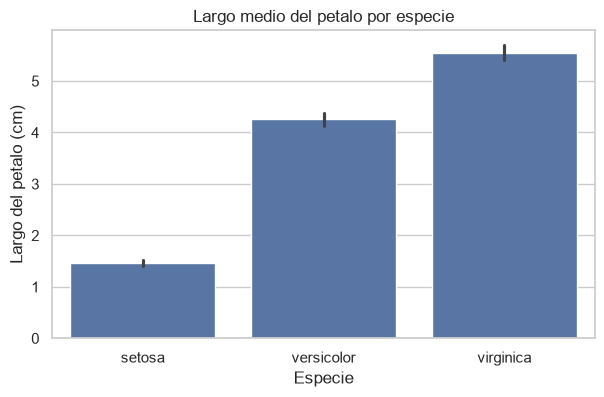

In [14]:
# 5.1 GRAFICO DE BARRAS: largo medio del petalo por especie
# barplot calcula automaticamente la media de cada grupo
plt.figure(figsize=(7, 4))  # tamano del lienzo (ancho, alto) en pulgadas
sns.barplot(data=df, x="species", y="petal_length")
plt.title("Largo medio del petalo por especie")  # titulo
plt.xlabel("Especie")  # etiqueta eje X
plt.ylabel("Largo del petalo (cm)")  # etiqueta eje Y
plt.show()  # muestra el grafico

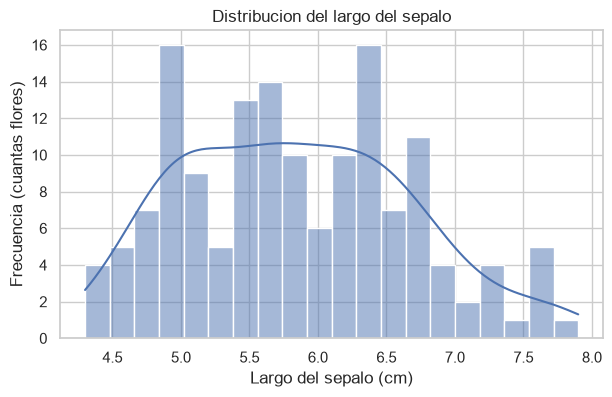

In [15]:
# 5.2 HISTOGRAMA: distribucion del largo del sepalo
# bins = numero de barras (intervalos). kde dibuja una curva suavizada encima
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="sepal_length", bins=20, kde=True)
plt.title("Distribucion del largo del sepalo")
plt.xlabel("Largo del sepalo (cm)")
plt.ylabel("Frecuencia (cuantas flores)")
plt.show()

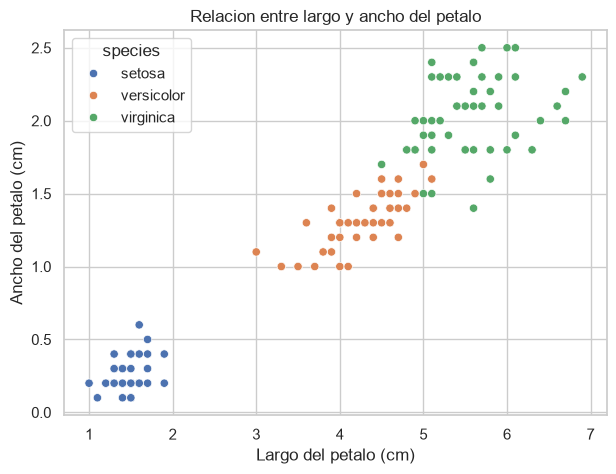

In [16]:
# 5.3 SCATTER PLOT: relacion entre largo y ancho del petalo
# hue="species" colorea cada punto segun su especie -> se ven 3 grupos claros
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("Relacion entre largo y ancho del petalo")
plt.xlabel("Largo del petalo (cm)")
plt.ylabel("Ancho del petalo (cm)")
plt.show()

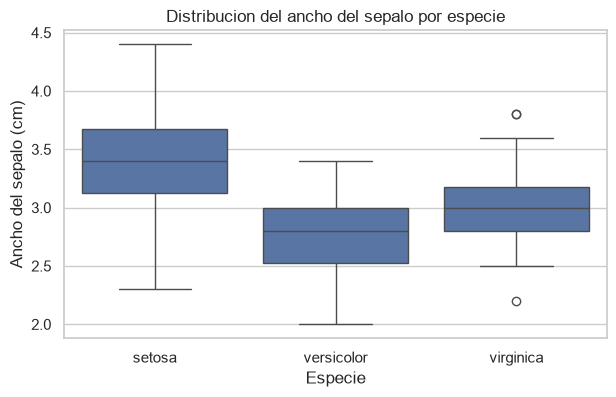

In [17]:
# 5.4 BOXPLOT: comparar la distribucion del ancho del sepalo por especie
# La 'caja' va del percentil 25 al 75; la linea central es la mediana;
# los puntos sueltos son posibles valores atipicos (outliers)
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="species", y="sepal_width")
plt.title("Distribucion del ancho del sepalo por especie")
plt.xlabel("Especie")
plt.ylabel("Ancho del sepalo (cm)")
plt.show()

### ✨ Gráfico interactivo con Plotly Express

Plotly genera gráficos con los que puedes **interactuar**: pasar el ratón para ver valores, hacer zoom o aislar categorías haciendo clic en la leyenda. Ideal para explorar y para reportes web.

In [18]:
# Scatter INTERACTIVO: mismas variables, pero ahora puedes pasar el raton encima
fig = px.scatter(
    df,
    x="petal_length",
    y="petal_width",
    color="species",          # un color por especie
    size="sepal_length",      # el tamano del punto refleja el largo del sepalo
    hover_data=["sepal_width"],  # info extra al pasar el raton
    title="Iris interactivo: petalo (largo vs ancho)",
)
fig.show()

## 6. 🎯 Mini reto

Ahora te toca a ti. **Duplica una celda de código** (o crea una nueva debajo) y prueba estos retos. ¡Equivocarse es parte de aprender!

1. **Cambia la variable del eje X:** en el histograma (5.2), usa `petal_length` en lugar de `sepal_length`. ¿Cambia la forma?
2. **Filtra otra categoría:** en el bloque 4.3, filtra `"setosa"` en vez de `"virginica"` y cuenta cuántas flores hay.
3. **Crea un gráfico nuevo:** haz un `sns.boxplot` del `petal_length` por `species`. ¿Qué especie tiene más dispersión?

> 💡 **Extra:** calcula la media de `petal_area` (la columna que creamos) por especie con `groupby`. ¿Cuál tiene los pétalos más grandes?

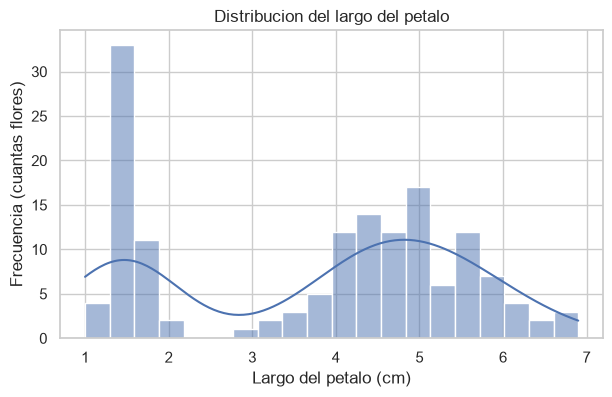

In [ ]:
# 5.X HISTOGRAMA
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="petal_length", bins=20, kde=True)
plt.title("Distribucion del largo del petalo")
plt.xlabel("Largo del petalo (cm)")
plt.ylabel("Frecuencia (cuantas flores)")
plt.show()


In [ ]:
# 4.X
setosa = df[df["species"] == "setosa"]

print("Numero de flores setosa:", setosa.shape[0])
setosa.head()

Numero de flores setosa: 50


,sepal_length,sepal_width,petal_length,petal_width,species,species_id,petal_area
0,5.1,3.5,1.4,0.2,setosa,1,0.28
1,4.9,3.0,1.4,0.2,setosa,1,0.28
2,4.7,3.2,1.3,0.2,setosa,1,0.26
3,4.6,3.1,1.5,0.2,setosa,1,0.30
4,5.0,3.6,1.4,0.2,setosa,1,0.28


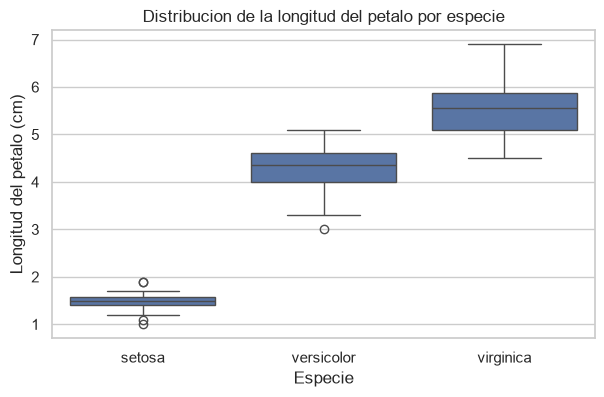

In [21]:
#Nuevo Gráfico
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="species", y="petal_length")
plt.title("Distribucion de la longitud del petalo por especie")
plt.xlabel("Especie")
plt.ylabel("Longitud del petalo (cm)")
plt.show()

In [43]:
#EXTRA
df.groupby("species").mean(numeric_only=True)["petal_area"]

species
setosa         0.3628
versicolor     5.7204
virginica     11.2962
Name: petal_area, dtype: float64

## 7. Buenas prácticas 📝

### Por qué comentar el código
Un comentario explica el **porqué** de una línea, no solo el qué. Dentro de 3 meses no recordarás por qué filtraste así. *Comentar = dejar notas a tu yo futuro.*

### Por qué dividir el notebook en secciones
Separar en bloques (importar → cargar → explorar → visualizar) hace que el análisis se **lea como una historia** y sea fácil de revisar y reutilizar.

### Cómo nombrar variables
- Usa nombres **descriptivos**: `virginica` mejor que `x` o `df2`.
- En minúsculas y con guion bajo: `petal_area`, `media_por_especie` (estilo *snake_case*).
- Evita tildes y espacios en los nombres.

### Cómo organizar un proyecto
Mantén una estructura clara: `notebooks/` para explorar, `src/` para código reutilizable, `data/` para los datos, y un `requirements.txt` con las dependencias. (Ver el `README.md` de este repositorio.)

## ✅ Checklist final

Ejecuta la siguiente celda: comprueba **automáticamente** que todo tu entorno funciona. Si ves todos los ✅, ¡tu configuración es perfecta!

In [41]:
# Esta celda verifica el entorno paso a paso e imprime un informe.
import sys

print("=" * 45)
print("        CHECKLIST DE TU ENTORNO")
print("=" * 45)

# 1) Comprobar que el kernel usa un entorno virtual (la ruta deberia incluir 'venv')
ruta_python = sys.executable
en_venv = ("venv" in ruta_python) or (sys.prefix != sys.base_prefix)
print(f"{'✅' if en_venv else '⚠️ '} Entorno virtual / kernel correcto")
print(f"     Python usado: {ruta_python}")

# 2) Comprobar cada libreria por separado
for nombre, modulo in [
    ("pandas", pd),
    ("matplotlib", plt),
    ("seaborn", sns),
    ("plotly", px),
]:
    print(f"✅ {nombre} funciona")

# 3) Comprobar que el dataset se cargo y tiene datos
print(f"Dataset Iris cargado ({df.shape[0]} filas, {df.shape[1]} columnas)")
print(f"Sin errores de importacion")

print("=" * 55)
print("  Si ves todos los ✅, ¡tu entorno esta listooooo! 🎉")
print("=" * 55)

        CHECKLIST DE TU ENTORNO
✅ Entorno virtual / kernel correcto
     Python usado: c:\Users\Usuario\Desktop\Curso Python FP\Python-setup_Ramon-Rojas\venv\Scripts\python.exe
✅ pandas funciona
✅ matplotlib funciona
✅ seaborn funciona
✅ plotly funciona
Dataset Iris cargado (150 filas, 7 columnas)
Sin errores de importacion
  Si ves todos los ✅, ¡tu entorno esta listooooo! 🎉


### 📋 Checklist manual

Repasa también estos puntos:

- [ ] El entorno virtual está activo (viste `(venv)` en la terminal al lanzar Jupyter/VS Code).
- [ ] pandas funciona (cargó la tabla y la mostró).
- [ ] matplotlib funciona (aparecieron los gráficos).
- [ ] seaborn funciona (barras, histograma, scatter y boxplot).
- [ ] Plotly funciona (el gráfico interactivo responde al ratón).
- [ ] Jupyter usa el kernel correcto (la celda de checklist muestra una ruta con `venv`).
- [ ] No aparecen errores de importación (ninguna celda dio `ModuleNotFoundError`).

---

Si has llegado hasta aquí ejecutando todo en orden, tu entorno de Python para Data Science está **correctamente configurado** y listo para proyectos.


Happy coding 🎉